# <center> ISEL - AA </center>
## <center>Semestre 2024/25 </center>
###  <center> Trabalho 1 - Pima Indians Diabetes Dataset</center>

Trabalho realizado por:
* Miguel Alcobia, numero <b> 50746 </b>
* Tomás Salvador, numero <b> 50766 </b>
* Rafael Dias, numero <b> 50773 </b>

<b> Turma 51D </b> <br></br>
<b> Docente: Gonçalo Marques </b>

### Introdução

O conjunto de dados Pima Indians Diabetes Database é amplamente utilizado para problemas de classificação, reunindo informações médicas de mulheres da etnia Pima com idades a partir de 21 anos. Contém 768 amostras e 8 variáveis independentes, como níveis de glicose, pressão arterial e índice de massa corporal (IMC), sendo a variável-alvo binária, indicando a presença ou ausência de diabetes. Neste trabalho, realizou-se o pré-processamento dos dados, incluindo a divisão em conjuntos de treino, validação e teste e no fim a normalização, seguido da aplicação de três classificadores: Random Forest, SVM e Logistic Regression.

A análise dos dados focou-se no ajuste de hiperparâmetros, que são parâmetros que controlam o comportamento dos classificadores utilizando técnicas como a subdivisão do conjunto de dados, como já foi referido anteriormente. As métricas de avaliação, como accuracy, precision, recall e F-score, foram utilizadas para comparar os três classificadores, complementadas por curvas ROC para analisar a sensibilidade de cada classificador. Também foi analisada a importância de ajustar os limiares de decisão para ajustar melhor os resultados desejados de acordo com o problema em questão, neste caso para reduzir o número de falsos negativos, que geralmente devem ser  reduzidos em problemas médicos para não correr o risco de atrasar a deteção das doenças. 

No final, também foi avaliado o impacto da normalização no desempenho dos classificadores. 

### Imports

In [115]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler

### Abrir o pickle

In [116]:
with open("pimaDiabetes.p", "rb") as data_file:
    D = pickle.load(data_file)

### Ver as chaves do dataset

In [117]:
# ver chaves
D.keys() 

dict_keys(['data', 'target', 'feature_names', 'DESCR'])

### Descrição do Dataset

In [118]:
print(D.DESCR)

This dataset is originally from the National
Institute of Diabetes and Digestive and Kidney Diseases.
The objective of the dataset is to diagnostically predict
whether or not a patient has diabetes, based on certain
diagnostic measurements included in the dataset.
Several constraints were placed on the selection of these
instances from a larger database. In particular, all patients
here are females at least 21 years old of Pima Indian heritage.
The dataset contains information of 768 women from a population
near Phoenix, Arizona, USA. The outcome tested was Diabetes,
268 tested positive and 500 tested negative.

For more inforamtion:
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S.
(1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus.
In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265).
IEEE Computer Society Press.


### Separação dos Dados e das suas classes

In [119]:
X = D['data']
y = D['target']

# Verificação de todas as classes do dataset
print(np.unique(y))

[0 1]


In [120]:
print("Caracteristicas do Dataset:\n")
for i in D ['feature_names']:
    print(i)

Caracteristicas do Dataset:

Number of times pregnant
Plasma glucose concentration at 2 Hours in an oral glucose tolerance test (GTIT)
Diastolic Blood Pressure (mm Hg)
Triceps skin fold thickness (mm)
2-Hour Serum insulin (µh/ml)
Body mass index [weight in kg/(Height in m)]
Diabetes pedigree function
Age (years)


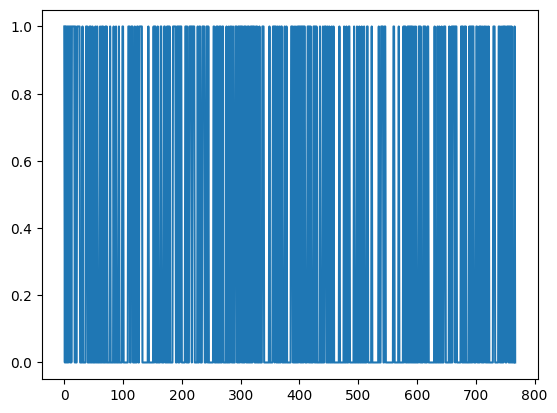

In [121]:
plt.plot(y)

O gráfico acima demonstra que os dados do dataset já se encontram baralhados, não sendo necessário por isso baralhá-los para a fase seguinte.

In [122]:
print("X shape", X.shape)
print("Y shape", y.shape)

X shape (768, 8)
Y shape (768,)


In [123]:
# número total de casos positivos e a probabilidade dos casos positivos em relação ao total
print("Casos positivos:", np.sum(y==1), "\tProb:", np.round(np.sum(y==1)/len(y),2))
# número total de casos negativos e a probabilidade dos casos negativos em relação ao total
print("Casos negativos:", np.sum(y==0), "\tProb:", np.round(np.sum(y==0)/len(y),2))

Casos positivos: 268 	Prob: 0.35
Casos negativos: 500 	Prob: 0.65


### Separação dos dados para o treino dos classificadores

Inicialmente dividiram-se os dados em três conjuntos: treino, validação e teste, para permitir uma análise mais robusta. Inicialmente, separou-se 70% dos dados para treino e validação, com o objetivo de encontrar os melhores hiperparâmetros. Esses 70% foram divididos em 50% para treino e 20% para validação. O conjunto de treino é utilizado para ajustar o classificador, através da análise de várias combinações de hiperparâmetros, enquanto o conjunto de validação é utilizado para avaliar o desempenho das combinações e identificar os hiperparâmetros ideias. Por fim, o conjunto de teste, que corresponde aos 30% finais dos dados, serve para avaliar a precisão do classificador ajustado. Esta divisão permite estimar com maior eficácia o desempenho do classificador com novos dados.

In [124]:
# Divisão dos dados para treino e teste (70-30)
# Dividiu-se o conjunto de treino em Treino e Validação para encontrar os hiperparametros. (50-20)

# Proporções de cada conjunto
treino_ratio = 0.50
valid_ratio = 0.20

# Tamanhos para cada conjunto
treino_size = int(X.shape[0] * treino_ratio)
valid_size = int(X.shape[0] * valid_ratio)

# Dividir X e y entre treino, validação e teste
X_train = X[:treino_size]
y_train = y[:treino_size]

X_valid = X[treino_size:treino_size + valid_size]
y_valid = y[treino_size:treino_size + valid_size]

X_test = X[treino_size + valid_size:]
y_test = y[treino_size + valid_size:]

# Print dos tamanhos de cada conjunto
print("Conjunto de treino:", X_train.shape, y_train.shape)
print("Conjunto de validação:", X_valid.shape, y_valid.shape)
print("Conjunto de teste:", X_test.shape, y_test.shape)

Conjunto de treino: (384, 8) (384,)
Conjunto de validação: (153, 8) (153,)
Conjunto de teste: (231, 8) (231,)


### Escolha dos Classificadores

O grupo escolheu os seguintes classificadores:

* Random Forest Classifier - Como é baseado num conjunto de árvores de decisão, pode ser muito eficaz quando há uma interação não linear entre as variáveis, como é o caso em muitos problemas médicos. O dataset dos índios Pima pode conter relações complexas entre as variáveis (como glicose, pressão arterial e idade) que o Random Forest consegue capturar melhor do que modelos lineares.

* SVM - No caso dos índios Pima, onde a separação entre quem tem e quem não tem diabetes pode não ser perfeitamente linear, o SVM com kernel pode ser usado para mapear os dados em um espaço de maior dimensão, onde a separação entre as classes se torna mais simples.

* Logistic Regression - Eficaz, para problemas de classificação binária. Como o objetivo é prever a probabilidade de uma paciente ter diabetes, a Regressão Logística pode ser uma boa escolha, pois fornece a probabilidade de uma classe específica (no caso, a presença ou não de diabetes no paciente) dada a combinação das variáveis do conjunto.

### RandomForest

O Random Forest é um dos algoritmos mais utilizados para problemas de classificação (como é o caso apresentado no trabalho) e regressão, devido à sua robustez e capacidade de funcionar bem para diferentes tipos de dados. No caso do Random Forest, o algoritmo utiliza várias árvores de decisão para realizar as previsões. Cada árvore de decisão contribui com um "voto" para a decisão final, sendo que a previsão mais frequente entre todas as árvores é considerada como o resultado final do classificador.

Este classificador constrói várias árvores de decisão, e cada uma vai ser treinada com um conjunto aleatório de dados de treino. Em cada nó da árvore, em cada uma delas, o classificador escolhe aleatoriamente uma subamostra de atributos. 

A técnica de escolha aleatória é o que torna o Random Forest resistente ao overfitting, um problema comum nas árvores de decisão individuais. Ao construir diversas árvores, cada uma treinada com uma amostra aleatória de dados, o classificador evita o ajuste excessivo aos dados de treino. Essa abordagem não só fortalece a resistência ao overfitting, como também contribui para uma elevada precisão na classificação. Ao juntar os resultados de várias árvores, o classificador torna-se mais robusto e menos suscetível a "ruídos" nos dados.

Para encontrar os melhores hiperparâmetros para o classificador Random Forest desemvolveu-se o código abaixo. Começa por testar diferentes combinações de valores para os três parâmetros principais: o número de árvores (``n_estimators``), a profundidade máxima de cada árvore (``max_depth``) e o número mínimo de amostras necessárias para dividir um nó (``min_samples_split``). Para cada combinação de valores, o classificador é treinado com o conjunto de dados de treino e avaliado com o conjunto de validaçã. A combinação de hiperparâmetros que dá origem à maior probabilidade de acertos é guardada e exibida no fim, com a probabilidade de acertos obtida.

In [ ]:
# Classificador RandomForest

def aval_rf(n_estimators, max_depth, min_samples_split, X_train, y_train, X_valid, y_valid):
    """aval_rf

    Args:
        n_estimators: Número de árvores na floresta
        max_depth: Profundidade máxima permitida para cada árvore
        min_samples_split: Número mínimo de amostras necessário para dividir um nó
        X_train: Conjunto de dados de treino
        y_train: Labels do conjunto de treino
        X_valid: Conjunto de dados de validação
        y_valid: Labels do conjunto de validação

    Returns:
        accuracy: Probabilidade de acertos do classificador
    """
    # Inicializar o classificador com os parâmetros da função
    rf = RandomForestClassifier(n_estimators=n_estimators,
                                max_depth=max_depth,
                                min_samples_split=min_samples_split,
                                random_state=42)
    
    # Treinar o modelo com o conjunto de dados de treino
    rf.fit(X_train, y_train)
    # Calcular a probabilidade de acertos do modelo com o conjunto de validação
    accuracy = rf.score(X_valid, y_valid)
    return accuracy

# Definir os valores dos hiperparâmetros
n_estimators_values = [50, 100, 200]  
max_depth_values = [None, 10, 20, 30]  
min_samples_split_values = [2, 5, 10]

# Variáveis para guardar os melhores parâmetros e a melhor probabilidade de acertos
best_accuracy = 0
best_params = {}

# Percorre todas as combinações dos valores de hiperparâmetros
for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for min_samples_split in min_samples_split_values:
            # Avaliar o modelo com a combinação atual de hiperparâmetros
            accuracy = aval_rf(n_estimators, max_depth, min_samples_split, X_train, y_train, X_valid, y_valid)
            #print(f"Precisão com n_estimators={n_estimators}, max_depth={max_depth}, min_samples_split={min_samples_split}: {accuracy:.4f}")
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split
                }

# Print dos resultados
print("\nMelhores parâmetros encontrados:")
print(best_params)
print(f"Precisão com os melhores parâmetros: {best_accuracy:.4f}")


Melhores parâmetros encontrados:
{'n_estimators': 200, 'max_depth': None, 'min_samples_split': 10}
Precisão com os melhores parâmetros: 0.8235


### SVM

O Support Vector Machine (SVM) é outro tipo de classificador muito utilizado para problemas de classificação. Ao contrário do Random Forest, o SVM constrói um modelo que identifica um ou mais hiperplanos de decisão, dividindo o espaço das amostras de modo a maximizar a margem entre as diferentes classes, o que aumenta a capacidade de classificação do modelo.

O SVM permite a utilização de diferentes kernels. Os kernels sáo as funções que mapeiam os dados para espaços de maior dimensão tornando o SVM flexível para resolver problemas com padrões de fronteiras mais complexos. Os tipos de ``kernel`` mais comuns incluem o ``linear``, ``rbf`` (função de base radial) e a ``sigmoid``. Para cada kernel, o algoritmo ajusta os parâmetros ``C`` (que controla a margem de erro do classificador) e a ``gamma`` (responsável por ajustar a influência de cada ponto da amostra), que juntos determinam a flexibilidade e o ajuste do classificador aos dados de treino.

O processo de ajuste de parâmetros do SVM é essencial para encontrar o equilíbrio ideal entre a precisão da classificação e a generalização, evitando tanto o overfitting quanto o underfitting. 

Para encontrar os melhores hiperparâmetros para o classificador SVM, foi desenvolvido o código abaixo. Primeiro testaram-se diferentes combinações de valores para os três parâmetros principais: o tipo de função de kernel (``kernel``), o parâmetro de regularização (``C``) e o parâmetro ``gamma``, que ajusta a influência a curvatura nas fronteiras de decisão.

Para cada combinação de valores, o modelo SVM é treinado utilizando o conjunto de treino e avaliado com o conjunto de validação, obtendo-se a probabilidade de acertos. O objetivo é maximizar a precisão do modelo através da escolha desses parâmetros. A combinação de hiperparâmetros que resulta na maior probabilidade de acertos é guardada e exibida ao final com a probabilidade de acertos obtida para essa configuração.

In [ ]:
# Classificador SVM

def aval_svm(kernel, C, gamma, X_train, y_train, X_valid, y_valid):
    """aval_svm

    Args:
        kernel: especifica o tipo de função de kernel a ser utilizada pelo SVM (por exemplo, 'linear', 'rbf', etc.)
        C: parâmetro de regularização que controla o grau de penalização de erros de classificação
        gamma: define a influência de cada ponto de dados (em kernels 'rbf', 'sigmoid' e 'poly')
        X_train: conjunto de dados de treino
        y_train: rótulos do conjunto de treino
        X_valid: conjunto de dados de validação
        y_valid: rótulos do conjunto de validação

    Returns:
        accuracy: precisão do modelo no conjunto de validação
    """
    
    # Inicializar o modelo SVM com os hiperparâmetros passados
    svm = SVC(kernel=kernel,
              C=C,
              gamma=gamma,
              random_state=42)
    
    # Treinar o modelo SVM com o conjunto de treino
    svm.fit(X_train, y_train)
    
    # Ver a probabilidade de acertos do modelo
    accuracy = svm.score(X_valid, y_valid)
    return accuracy

# Valores dos hiperparâmetros a ser testados
# Testou-se o kernel "poly", mas demorava muito tempo e encravava o PC
kernels = ['linear', 'rbf', 'sigmoid']   
C_values = [0.1, 1, 10] 
gamma_values = ['scale', 'auto'] 

# Variáveis para guardar a melhor probabilidade de acertos e os melhores parâmetros encontrados
best_accuracy = 0
best_params = {}

# Percorrer todas as combinações possíveis dos hiperparâmetros
for kernel in kernels:
    for C in C_values:
        for gamma in gamma_values:
            # Avaliar o modelo SVM com a combinação atual de hiperparâmetros
            accuracy = aval_svm(kernel, C, gamma, X_train, y_train, X_valid, y_valid)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'kernel': kernel,
                    'C': C,
                    'gamma': gamma
                }

# Print dos resultados
print("\nMelhores parâmetros encontrados:")
print(best_params)
print(f"Precisão com os melhores parâmetros: {best_accuracy:.4f}")


Melhores parâmetros encontrados:
{'kernel': 'linear', 'C': 1, 'gamma': 'scale'}
Precisão com os melhores parâmetros: 0.8235


### LogisticRegression

O classificador de Regressão Logística é um dos métodos mais utilizados para resolver problemas de classificação binária. Trata-se de um modelo estatístico que estima a probabilidade de uma amostra pertencer a uma das classes, usando uma função logística para mapear os valores previstos. O objetivo principal do modelo é encontrar um limite de decisão que divida o espaço das amostras de forma a maximizar a distinção entre as classes.

A Regressão Logística é vantajosa pela sua simplicidade. Este classificador é controlado por hiperparâmetros importantes, como ``C``, que regula a regularização (que controla a complexidade do modelo para evitar overfitting) e ``penalty``, que determina o tipo de regularização a ser aplicado (``l1`` ou ``l2``). O ``solver`` é outro hiperparâmetro crucial que define o método de otimização para encontrar os melhores coeficientes do classificador.

O código abaixo utiliza a função aval_lr para encontrar a melhor combinação de hiperparâmetros para o modelo de Regressão Logística. A função percorre valores para C, penalty, e solver, treinando e avaliando o modelo em cada combinação com um conjunto de validação. No fim, a combinação de hiperparâmetros que resulta na maior precisão é guardada, o que permite obter um modelo mais adequado aos dados e ao objetivo da classificação.

In [ ]:
# Classificador LogisticRegression

def aval_lr(C, penalty, solver, X_train, y_train, X_valid, y_valid):
    """aval_lr

    Args:
        C: Coeficiente de regularização. Controla a penalização aplicada aos coeficientes do modelo.
        penalty: Tipo de penalização aplicada aos coeficientes do modelo ('l1' ou 'l2').
        solver: Algoritmo de otimização a ser utilizado para ajustar o modelo.
        X_train: Conjunto de dados de treino.
        y_train: Rótulos do conjunto de treino.
        X_valid: Conjunto de dados de validação.
        y_valid: Rótulos do conjunto de validação.

    Returns:
        accuracy: Probabilidade de acertos do modelo avaliado no conjunto de validação.
    """
    # Criar o modelo de Regressão Logística com os hiperparâmetros especificados
    lr = LogisticRegression(C=C,
                            penalty=penalty,
                            solver=solver,
                            random_state=42,
                            max_iter=1000)
    
    # Treinar o classificador com o conjunto de treino
    lr.fit(X_train, y_train)
    
    # Calcular a probabilidade de acertos no conjunto de validação
    accuracy = lr.score(X_valid, y_valid)
    return accuracy

# Definir os valores dos hiperparâmetros a testar
C_values = [0.01, 0.1, 1, 10]  
penalty_values = ['l1','l2']  # 'l1' também pode ser usado, dependendo do solver
solver_values = ['lbfgs', 'liblinear']  # Alguns solvers são compatíveis apenas com certos tipos de penalty  

# Variáveis para guardar os melhores parâmetros e a melhor probabilidade de acertos
best_accuracy = 0
best_params = {}

# Testar todas as combinações de valores para os hiperparâmetros
for C in C_values:
    for penalty in penalty_values:
        for solver in solver_values:
            # Verificar se o solver é compatível com o tipo de penalização
            if penalty == 'l1' and solver not in ['liblinear']:
                continue  # Ignora combinações de penalty e solver incompatíveis
            
            # Avaliar o modelo com a combinação atual de hiperparâmetros
            accuracy = aval_lr(C, penalty, solver, X_train, y_train, X_valid, y_valid)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'C': C,
                    'penalty': penalty,
                    'solver': solver
                }

# Plot dos resultados
print("\nMelhores parâmetros encontrados:")
print(best_params)
print(f"Precisão com os melhores parâmetros: {best_accuracy:.4f}")


Melhores parâmetros encontrados:
{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Precisão com os melhores parâmetros: 0.8235


### Métricas

Os melhores hiperparâmetros para cada classificador foram encontrados na fase anterior e agora vão ser utilizados novamente para analisar as métricas de cada classificador. 

Para o classificador Random Forest, os parâmetros ideais incluem ``n_estimators=200``, ``max_depth=None`` (sem limite de profundidade para as árvores) e ``min_samples_split=10``, o que significa que uma divisão de nó só ocorre se houver pelo menos 10 amostras nesse nó.

No caso do SVM, a melhor configuração encontrada utiliza um kernel ``linear``, com ``C=1`` e ``gamma='scale'`` . 

Para a Regressão Logística, a configuração ótima encontrada foi ``C=0.01``, ``penalty='l2'`` e ``solver='lbfgs'``.

Passou-se então á análise das metricas com estes parametros.

In [128]:
# {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 10}
random_forest = RandomForestClassifier(n_estimators=200, max_depth=None,min_samples_split=10, random_state=42)

#{'kernel': 'linear', 'C': 1, 'gamma': 'scale'}
svm = SVC(kernel='linear', C=1, gamma='scale', probability=True)

#{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
logistic_regression = LogisticRegression(C=0.01, penalty='l2', solver='lbfgs', max_iter=200)

Inicialmente juntou-se o conjunto de dados de treino com o conjunto de dados de validação, uma vez que essa separação era Útil na fase de procura pelos melhores hiperparametros, visto que esse objetivo já foi alcançado, podem juntar-se os conjuntos. Posto isto, passou-se á análise dos resultados para cada classificador. Para tal, após calcular a matriz de confusão, obteve-se a Probabilidade total de acertos, a Precisão, o Recall e o F-Score.

In [129]:
# Combina os dados de treino (X_train, y_train) e validação (X_valid, y_valid) num único conjunto para reavaliar o modelo 
# com mais dados durante o treino.
X_combined = np.concatenate((X_train, X_valid), axis=0)
y_combined = np.concatenate((y_train, y_valid), axis=0)

# avaliar o desempenho de um classificador em conjunto de teste
def aval_clf(clf, X_train, y_train, X_test, y_test):
    # nome da classe do modelo para identificar o classificador avaliado
    print(f"Avaliação - {clf.__class__.__name__} ")
    
    # Treina o classificador com os dados de treino
    clf.fit(X_train, y_train)
    
    # previsões sobre o conjunto de teste.
    y_pred = np.array(clf.predict(X_test))
    
    # Calcular a matriz de confusão 
    conf_matrix = confusion_matrix(y_test, y_pred)

    print("Matriz de Confusão:")
    print(conf_matrix)

    TN, FP, FN, TP = conf_matrix.ravel()

    # Percentagem total de classificações corretas
    accuracy = (TP + TN) / (TP + FP + TN + FN)
    # Percentagem das previsões positivas que são realmente corretas
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    # Percentagem dos casos positivos corretamente identificados
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    # Média entre precision e recall para equilibrar os dois
    f_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Print dos resultados das métricas calculadas.
    print()
    print("Probabilidade total de acertos:", np.round(accuracy, 4))
    print("Precision:", np.round(precision, 4))
    print("Recall:", np.round(recall, 4))
    print("F-Score:", np.round(f_score, 4))

### Métricas do RandomForest

In [130]:
aval_clf(random_forest, X_combined, y_combined, X_test, y_test)

Avaliação - RandomForestClassifier 
Matriz de Confusão:
[[138  14]
 [ 33  46]]

Probabilidade total de acertos: 0.7965
Precision: 0.7667
Recall: 0.5823
F-Score: 0.6619


Com base nos resultados obtidos para o classificador Random Forest ao avaliar o conjunto de teste do dataset, observa-se um desempenho geral satisfatório, mas com margem para melhorias em termos de sensibilidade. A matriz de confusão mostra que o modelo classificou corretamente 138 verdadeiros negativos e 46 positivos verdadeiros, mas cometeu 33 falsos negativos e 14 falsos positivos.

A probabilidade total de acertos é de 79,65%, indicando que o modelo tem um bom desempenho geral para prever corretamente os resultados. No entanto, o recall 58,23%, que mede a proporção de verdadeiros positivos identificados corretamente, é mais baixo, sugerindo que o modelo teve algumas dificuldades em identificar alguns dos casos positivos (pessoas que têm diabetes). Por outro lado, a precisão 76,67% indica uma boa capacidade do modelo em evitar falsos positivos, o que é importante para evitar alarmes desnecessários. O F-Score 66,19%, que é uma métrica combinada de precisão e recall, revela um equilíbrio moderado entre ambas.

### Métricas do SVM

In [131]:
aval_clf(svm, X_combined, y_combined, X_test, y_test)

Avaliação - SVC 
Matriz de Confusão:
[[137  15]
 [ 37  42]]

Probabilidade total de acertos: 0.7749
Precision: 0.7368
Recall: 0.5316
F-Score: 0.6176


O desempenho do classificador SVM ao avaliar o conjunto de teste apresenta resultados satisfatórios em termos gerais, porém indica algumas limitações no reconhecimento de casos positivos. A matriz de confusão revela 137 negativos verdadeiros e 42 positivos verdadeiros, mas também 37 falsos negativos e 15 falsos positivos.

A probabilidade total de acertos é de 77,49%, demonstrando que o modelo realizou previsões corretas na maior parte dos casos. A precisão 73,68% sugere que o modelo tem uma boa capacidade de evitar falsos positivos, o que é importante para minimizar diagnósticos incorretos de diabetes em pessoas saudáveis. No entanto, o recall 53,16%, que avalia a proporção de positivos identificados corretamente, é relativamente baixo, indicando que o modelo deixou de identificar muitos casos de diabetes. O F-Score (61,76%) reflete um equilíbrio entre a precisão e o recall.

### Métricas do LogisticRegression

In [132]:
aval_clf(logistic_regression, X_combined, y_combined, X_test, y_test)

Avaliação - LogisticRegression 
Matriz de Confusão:
[[137  15]
 [ 34  45]]

Probabilidade total de acertos: 0.7879
Precision: 0.75
Recall: 0.5696
F-Score: 0.6475


O desempenho do classificador Logistic Regression ao avaliar o conjunto de teste do dataset apresenta resultados satisfatórios, mas também apresenta algumas limitações. A matriz de confusão mostra 137 negativos verdadeiros e 45 positivos verdadeiros, enquanto existem 34 falsos negativos e 15 falsos positivos.

A probabilidade total de acertos accuracy é de 78,79%, indicando que o modelo realiza previsões corretas na maior parte dos casos. A precisão 75,00% mostra que o modelo tem uma boa capacidade de evitar falsos positivos, crucial para não diagnosticar diabetes em pessoas saudáveis de forma errada. O recall 56,96%, demonstra alguma dificuldade em classificar corretamente todos os casos positivos, o que resulta em falsos negativos. O F-Score (64,75%), que equilibra precisão e recall, é razoavelmente bom, refletindo o desempenho geral do modelo.

### Calibração

Em problemas como a previsão de diabetes, é crucial minimizar o número de falsos negativos, ou seja, os casos em que o modelo não consegue identificar corretamente pacientes que têm diabetes. Isto porque um falso negativo pode levar à falta de tratamento e, consequentemente, a complicações mais graves. A análise dos resultados dos classificadores anteriores revelaram que o número de falsos negativos está demasiado elevado, de acordo com o tipo de dados que estão a ser analisados. 

Com a abordagem iremos aumentar os falsos positivos, mas é preferível ter uma pessoa cujo o teste acusa diabetes e vêm a verificar depois que não é verdade, do que atrasar o tratamento de alguém que está com diabetes no caso de ser falso negativo.

Para lidar com o elevado número de falsos negativos, foi necessário ajustar o limiar de decisão (threshold) dos modelos. O limiar padrão de 0.5 define que uma instância será classificada como positiva se a probabilidade prevista pelo modelo for maior ou igual a 50%. No entanto, para problemas como a previsão de diabetes, é vantajoso diminuir esse limiar, tornando o modelo mais sensível à identificação de casos positivos, mesmo que isso aumente ligeiramente o número de falsos positivos. 

Este ajuste foi realizado através da análise da curva ROC, que avalia o desempenho dos modelos com diferentes limiares, permitindo identificar o ponto ideal que aumenta a sensibilidade (taxa de verdadeiros positivos), reduzindo os falsos negativos sem comprometer excessivamente outras métricas.

Para implementar esta abordagem, foi desenvolvido o código seguinte que ajusta dinamicamente o limiar de decisão dos classificadores. A partir da curva ROC, determinou-se um limiar que atinjisse uma taxa de verdadeiros positivos (TPR) de pelo menos 90%, aumentando a sensibilidade do modelo. Após determinar os limiares ideais, os modelos foram reavaliados utilizando esses novos valores. 

Este processo garante que os modelos estejam melhor ajustados a este problema, priorizando a identificação correta de casos de pacientes com diabetes.

In [133]:
# avaliação as métricas de um classificador com ajuste de threshold
def aval_metrics_clf(clf, X_train, y_train, X_test, y_test, threshold=0.5):
    
    print(f"Avaliação - {clf.__class__.__name__} com threshold = {threshold}")
    # Lista para guardar as métricas calculadas
    metrics = []  

    # Treina o modelo com os dados de treino
    clf.fit(X_train, y_train)
    
    # Obter as probabilidades previstas para a classe positiva (classe 1)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    # Ajustar as previsões com base no threshold escolhido
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # matriz de confusão
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Matriz de Confusão:")
    print(conf_matrix)
    
    TN, FP, FN, TP = conf_matrix.ravel()
    
    # Cálculo das métricas de avaliação
    accuracy = (TP + TN) / (TP + FP + TN + FN)  
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0  
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0  
    f_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0  

    # Print das métricas calculadas
    print("\nProbabilidade total de acertos:", np.round(accuracy, 4))
    print("Precision:", np.round(precision, 4))
    print("Recall:", np.round(recall, 4))
    print("F-Score:", np.round(f_score, 4))

    # Guardar as métricas e o nome do classificador numa lista
    metrics.append(clf.__class__.__name__)  
    metrics.append(accuracy)  
    metrics.append(precision)  
    metrics.append(recall)  
    metrics.append(f_score)  

    return y_pred_proba, conf_matrix.ravel(), metrics
    

# ajuste do melhor threshold para cada classificador
def descobrir_limirar_clfs(clfs):
    # Lista para guardar os limiares ajustados para cada classificador
    limiares_escolhidos = []  

    for clf in clfs:
        # Calcular a curva ROC (FPR, TPR e thresholds) com base nas probabilidades previstas
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        
        # Definir o TPR (taxa de verdadeiros positivos) desejado
        tpr_threshold = 0.9
        # Encontrar o índice do limiar que atinge ou supera o TPR desejado
        index = np.argmax(tpr >= tpr_threshold)
        # obtém o threshold correspondente
        chosen_threshold = thresholds[index]
        limiares_escolhidos.append(chosen_threshold)
        
        # Print do limiar ajustado para o classificador
        print(f"Limiar ajustado para {clf.__class__.__name__}: {np.round(chosen_threshold, 3)}")
    
    # Retorna os limiares ajustados para cada classificador
    return limiares_escolhidos

# Lista dos classificadores usados
classificadores = [random_forest, svm, logistic_regression]
# Ajustar os thresholds para cada classificador com base na curva ROC
thresholds = descobrir_limirar_clfs(classificadores)

Limiar ajustado para RandomForestClassifier: 0.258
Limiar ajustado para SVC: 0.258
Limiar ajustado para LogisticRegression: 0.27


### Métricas Recalculadas do RandomForest

In [134]:
avalM_RF = aval_metrics_clf(random_forest, X_combined, y_combined, X_test, y_test, thresholds[0])

Avaliação - RandomForestClassifier com threshold = 0.25818617697661805
Matriz de Confusão:
[[95 57]
 [ 7 72]]

Probabilidade total de acertos: 0.7229
Precision: 0.5581
Recall: 0.9114
F-Score: 0.6923


Após ajustar o limiar de decisão para 0.258, os resultados do RandomForestClassifier mostraram algumas mudanças significativas. A precisão diminuiu de 0.7667 para 0.5581, o que indica um aumento nos falsos positivos, mas o recall subiu consideravelmente de 0.5823 para 0.9114, indicando uma melhoria na identificação de casos positivos (verdadeiros positivos). Embora a precisão geral tenha caído de 0.7965 para 0.7229, o F-score aumentou ligeiramente, o que mostra que o modelo se tornou mais eficaz na identificação dos casos de diabetes, reduzindo significativamente os falsos negativos. Isto demonstra que o ajuste do limiar ajudou a priorizar a detecção de pacientes com diabetes, conforme o objetivo.

### Métricas Recalculadas do SVM

In [168]:
avalM_SVM = aval_metrics_clf(svm, X_combined, y_combined, X_test, y_test, thresholds[1])

Avaliação - SVC com threshold = 0.2617436371442539
Matriz de Confusão:
[[100  52]
 [  7  72]]

Probabilidade total de acertos: 0.7446
Precision: 0.5806
Recall: 0.9114
F-Score: 0.7094


Após ajustar o limiar de decisão para 0.261, os resultados do SVC também apresentaram mudanças notáveis. A precisão caiu de 0.7368 para 0.5806, indicando um aumento dos falsos positivos, mas o recall subiu significativamente de 0.5316 para 0.9114, o que demonstra uma melhoria na capacidade do modelo ao identificar casos positivos (verdadeiros positivos). A probabilidade total de acertos diminuiu de 0.7749 para 0.7446, mas o F-score aumentou de 0.6176 para 0.7094, indicando um desempenho melhor em termos de equilíbrio entre precisão e recall.

**Nota:** A cada fez que se dá run os valores mudam ligeiramente nesta célula

### Métricas do Recalculadas LogisticRegression

In [136]:
avalM_LR = aval_metrics_clf(logistic_regression, X_combined, y_combined, X_test, y_test, thresholds[2])

Avaliação - LogisticRegression com threshold = 0.2703175394976814
Matriz de Confusão:
[[102  50]
 [  7  72]]

Probabilidade total de acertos: 0.7532
Precision: 0.5902
Recall: 0.9114
F-Score: 0.7164


Após ajustar o limiar de decisão para 0.270, os resultados do modelo de regressão logística mostraram mudanças significativas. A precisão diminuiu de 0.75 para 0.5902, refletindo um aumento nos falsos positivos. No entanto, o recall subiu consideravelmente, de 0.5696 para 0.9114, o que indica uma melhoria significativa na capacidade do modelo de identificar corretamente os casos positivos. A Probabilidade total de acertos também caiu de 0.7879 para 0.7532, mas o F-score aumentou de 0.6475 para 0.7164, indicando um melhor equilíbrio entre precisão e recall.

As alterações feitas ao ajustar o limiar de decisão dos vários modelos resultaram numa redução significativa no número de falsos negativos, melhorando a sensibilidade geral para a identificação de pacientes com diabetes. Embora tenha havido um leve "sacrifício" na precisão, o aumento do recall e do F-score reflete uma classificação mais equilibrada e focada na detecção de casos positivos. Desta forma, foi possivel reduzir o número de falsos negativos e melhorar a detecção de pacientes com diabetes,  melhorando a eficácia para prever a presença da doença e tomar medidas preventivas adequadas.

### Curva ROC Comparativa dos 3 Classificadores

A Curva ROC (Receiver Operating Characteristic) é usada para avaliar o desempenho de classificadores binários, mostrando a relação entre a Taxa de Verdadeiros Positivos (TPR) e a Taxa de Falsos Positivos (FPR) para diferentes limiares. 

O eixo X representa a FPR , enquanto o eixo Y mostra a TPR. A Área sob a Curva quantifica o desempenho geral do modelo, quando o valor é próximo de 1 indica uma alta capacidade de separação entre as classes, já valores próximos de 0.5 indicam um desempenho aleatório.

Os pontos vermelhos no gráfico indicam o desempenho real de cada modelo com base no limiar ajustado, considerando a matriz de confusão. Esses pontos representam os valores calculados de FPR e TPR após o ajuste, o que ajuda a visualizar a forma como os classificadores equilibram falsos positivos e verdadeiros positivos. Um ponto próximo do canto superior esquerdo da curva indica um bom desempenho que combina uma alta sensibilidade do classificador com uma baixa taxa de erros. Assim, este gráfico permite comparar os modelos (Random Forest, SVM e Regressão Logística) e avaliar o impacto do ajuste do limiar nos resultados.

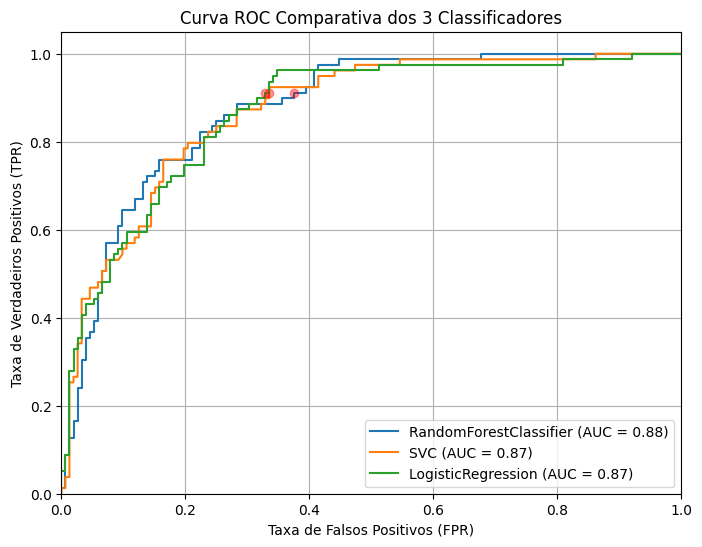

In [137]:
def roc_curve_grafDraw(clf, y_pred_proba, conf_matrix):
    # tamanho da figura para o gráfico
    plt.figure(figsize=(8, 6))
    
    # Percorrer os valores utilizados para construir a curva
    for clf, y_pred_proba, conf_matrix in zip(clfs, y_pred_probas, conf_matrix):
        # Calcular os valores para a curva ROC
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        
        # Calcular a área sob a curva ROC (AUC - Area Under Curve)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        # Plot da curva ROC para o classificador atual
        plt.plot(fpr, tpr, label=f"{clf.__class__.__name__} (AUC = {roc_auc:.2f})")
        
        TN, FP, FN, TP = conf_matrix.ravel()
        
        # Adiciona um ponto no gráfico da posição da métrica baseada em TP e FP
        # FP rate: FP / (TN + FP)
        # TP rate: TP / (TP + FN)
        plt.plot(FP / (TN + FP), TP / (TP + FN), 'or', alpha=0.4) 
    
    # gráfico
    plt.grid(True)
    plt.xlim([0.0, 1.0])  # Limites do eixo X
    plt.ylim([0.0, 1.05])  # Limites do eixo Y
    plt.xlabel("Taxa de Falsos Positivos (FPR)")
    plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
    plt.title("Curva ROC Comparativa dos 3 Classificadores") 
    plt.legend(loc="lower right")
    plt.show()  

# Lista dos classificadores usados
clfs = [random_forest, svm, logistic_regression]

# Lista das probabilidades preditas para cada classificador 
y_pred_probas = [avalM_RF[0], avalM_SVM[0], avalM_LR[0]]

# Lista das matrizes de confusão associadas a cada classificador
conf_matrix = [avalM_RF[1], avalM_SVM[1], avalM_LR[1]]

# desenhar a curva
roc_curve_grafDraw(clfs, y_pred_probas, conf_matrix)

Após a análise das curvas, pode ver-se que o Random Forest (linha azul) apresenta uma ligeira vantagem com uma AUC (Área sob a Curva) de 0.88, revelando uma maior capacidade em distinguir as classes positivas das negativas nos três modelos. A curva está consistentemente acima das outras em várias regiões do gráfico, o que sugere que o modelo é robusto comparativamente aos outros dois classificadores testados.

O SVM (linha laranja) e o classificador da Regressão Logística (linha verde) possuem desempenhos muito semelhantes, ambos com uma AUC de 0.87. As curvas dos dois classificadores são relativamente próximas, o que mostra que têm uma capacidade de classificação  idêntica. 

Os pontos vermelhos que representam os limiares ajustados, estão próximos do topo das curvas, indicando que os ajustes realizados nos limiares foram eficazes para melhorar a sensibilidade (TPR) ao reduzir os falsos negativos, mesmo que isso tenha resultado no aumento na FPR.

No geral, todos os modelos possuem um bom desempenho com uma AUC acima de 0.85, mas o Random Forest destaca-se como o melhor classificador para este conjunto de dados, enquanto a SVM e a Regressão Logística apresentam  bons desempanhos e praticamente equivalentes.

# Normalizar os dados

Após a preparação e análise inicial dos dados, passou-se à normalização dos dados. A normalização é um processo de transformação das variáveis para que todas possuam a mesma escala, ou seja, uma média de 0 e um desvio padrão de 1.

In [138]:
# inicialização do objeto StandardScaler para normalizar os dados
scaler = StandardScaler()

# ajustar o scaler aos dados de treino e transforma esses dados para terem a média 0 e desvio padrão 1.
X_train = scaler.fit_transform(X_train)

# transformação do conjunto de validação, que é feito com o scaler já ajustado aos dados de treino, 
X_valid = scaler.transform(X_valid)

# Transformação do conjunto de teste
X_test = scaler.transform(X_test)

# verificar os tamanhos dos conjuntos após a normalização
print("Conjunto de treino:", X_train.shape, y_train.shape)
print("Conjunto de validação:", X_valid.shape, y_valid.shape)
print("Conjunto de teste:", X_test.shape, y_test.shape)

# matriz de covariância do conjunto de treino normalizado.
# rowvar=False garante que cada coluna seja tratada como uma variável (features)
cov_matrix = np.round(np.cov(X_train, rowvar=False), 2)

print("\nMatriz de Covariância:\n", cov_matrix)

# guardar a diagonal da matriz de covariância
diagonal = np.diag(cov_matrix)
print("\nDiagonal da Matriz de Covariância (variância):\n", diagonal)

Conjunto de treino: (384, 8) (384,)
Conjunto de validação: (153, 8) (153,)
Conjunto de teste: (231, 8) (231,)

Matriz de Covariância:
 [[ 1.    0.19  0.1  -0.06 -0.02  0.07 -0.05  0.56]
 [ 0.19  1.    0.1  -0.01  0.37  0.21  0.18  0.32]
 [ 0.1   0.1   1.    0.14  0.08  0.22 -0.03  0.24]
 [-0.06 -0.01  0.14  1.    0.46  0.34  0.17 -0.15]
 [-0.02  0.37  0.08  0.46  1.    0.19  0.23  0.03]
 [ 0.07  0.21  0.22  0.34  0.19  1.    0.09  0.09]
 [-0.05  0.18 -0.03  0.17  0.23  0.09  1.    0.04]
 [ 0.56  0.32  0.24 -0.15  0.03  0.09  0.04  1.  ]]

Diagonal da Matriz de Covariância (variância):
 [1. 1. 1. 1. 1. 1. 1. 1.]


Após a normalização dos dados, os conjuntos de treino, validação e teste possuem agora o mesmo formato, com 8 características cada e o número correspondente de instâncias. A normalização foi bem-sucedida, e as variáveis possuem média de zero e desvio padrão igual a um. A matriz de covariância obtida mostra as relações entre as variáveis. Os valores das entradas fora da diagonal indicam a correlação entre as variáveis, com valores próximos de 1 ou -1, que arredondados dão 0. A diagonal da matriz mostra as variâncias das variáveis, que após a normalização, são todas iguais a 1, o que indica que todas as características têm a mesma importância no processo de treino. Isso é fundamental para garantir que o modelo não é influenciado desproporcionalmente por variáveis com escalas muito diferentes.

## Testes com dados normalizados

Após a normalização foram procurados outra vez os hiperparametros e analisadas novamente as métricas para cada classificador.

### Hiperparametros do RandomForest com os Dados Normalizados

In [139]:
# valores dos hiperparâmetros que vão ser testados
n_estimators_values = [50, 100, 200]
max_depth_values = [None, 10, 20, 30]
min_samples_split_values = [2, 5, 10]

best_accuracy = 0
best_params = {}

# Testar todas as combinações dos hiperparâmetros
for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for min_samples_split in min_samples_split_values:
            # Avaliar a precisão do modelo para os parâmetros atuais
            accuracy = aval_rf(n_estimators, max_depth, min_samples_split, X_train, y_train, X_valid, y_valid)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split
                }

# Exibir os melhores parâmetros e a precisão obtida
print("\nMelhores parâmetros encontrados:")
print(best_params)
print(f"Precisão com os melhores parâmetros: {best_accuracy:.4f}")


Melhores parâmetros encontrados:
{'n_estimators': 200, 'max_depth': None, 'min_samples_split': 10}
Precisão com os melhores parâmetros: 0.8170


### Hiperparametros do SVM com os Dados Normalizados

In [140]:
# Definir os valores dos hiperparâmetros a testar
# Tipos de kernel para o SVM
kernels = ['linear', 'rbf', 'sigmoid']  
# Valores de C para controlar a penalização
C_values = [0.1, 1, 10]  
# Valores possíveis para o parâmetro gamma
gamma_values = ['scale', 'auto']  

best_accuracy = 0
best_params = {}

# Testar todas as combinações dos hiperparâmetros
for kernel in kernels:
    for C in C_values:
        for gamma in gamma_values:
            # Avaliar a precisão do modelo com a combinação atual de hiperparâmetros
            accuracy = aval_svm(kernel, C, gamma, X_train, y_train, X_valid, y_valid)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'kernel': kernel,
                    'C': C,
                    'gamma': gamma
                }

# Exibir os melhores parâmetros e a precisão obtida
print("\nMelhores parâmetros encontrados:")
print(best_params)
print(f"Precisão com os melhores parâmetros: {best_accuracy:.4f}")


Melhores parâmetros encontrados:
{'kernel': 'linear', 'C': 10, 'gamma': 'scale'}
Precisão com os melhores parâmetros: 0.8105


### Hiperparametros do LogisticRegression com os Dados Normalizados

In [141]:
# Definir os valores dos hiperparâmetros a testar
# Valores de C para regularização
C_values = [0.01, 0.1, 1, 10]
# Tipo de penalização
penalty_values = ['l1', 'l2']  
 # Solvers disponíveis para ajuste do modelo
solver_values = ['lbfgs', 'liblinear'] 

best_accuracy = 0
best_params = {}

# Testar todas as combinações dos hiperparâmetros
for C in C_values:
    for penalty in penalty_values:
        for solver in solver_values:
            # Verificar se o solver é compatível com o tipo de penalidade
            if penalty == 'l1' and solver not in ['liblinear']:
                continue  
            
            # Avaliar a precisão do modelo com a combinação atual de hiperparâmetros
            accuracy = aval_lr(C, penalty, solver, X_train, y_train, X_valid, y_valid)
            
            # atualizar os melhores parâmetros se a precisão for maior
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'C': C,
                    'penalty': penalty,
                    'solver': solver
                }

# Print os melhores parâmetros e a precisão obtida
print("\nMelhores parâmetros encontrados:")
print(best_params)
print(f"Precisão com os melhores parâmetros: {best_accuracy:.4f}")


Melhores parâmetros encontrados:
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Precisão com os melhores parâmetros: 0.8039


### Métricas com os Dados Normalizados

In [142]:
#{'n_estimators': 200, 'max_depth': None, 'min_samples_split': 10}
random_forest_N = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=10, random_state=42)

#{'kernel': 'linear', 'C': 10, 'gamma': 'scale'}
svm_N = SVC(kernel='linear', C=10, gamma='scale', probability=True)

#{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
logistic_regression_N = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=200)

X_combined = np.concatenate((X_train, X_valid), axis=0)
y_combined = np.concatenate((y_train, y_valid), axis=0)

### RandomForest

In [143]:
aval_clf(random_forest_N, X_combined, y_combined, X_test, y_test)

Avaliação - RandomForestClassifier 
Matriz de Confusão:
[[138  14]
 [ 33  46]]

Probabilidade total de acertos: 0.7965
Precision: 0.7667
Recall: 0.5823
F-Score: 0.6619


### SVM

In [144]:
aval_clf(svm_N, X_combined, y_combined, X_test, y_test)

Avaliação - SVC 
Matriz de Confusão:
[[138  14]
 [ 37  42]]

Probabilidade total de acertos: 0.7792
Precision: 0.75
Recall: 0.5316
F-Score: 0.6222


### LogisticRegression

In [145]:
aval_clf(logistic_regression_N, X_combined, y_combined, X_test, y_test)

Avaliação - LogisticRegression 
Matriz de Confusão:
[[140  12]
 [ 37  42]]

Probabilidade total de acertos: 0.7879
Precision: 0.7778
Recall: 0.5316
F-Score: 0.6316


Após a análise das métricas dos dados normalizados, é necessário encontrar o threshold adequado para uma comparação mais fidedigna.

### Métricas com os Dados Normalizados e com o Threshold Ajustado

In [146]:
# Executar com o threshold ajustado para reduzir o nºfalsos negativos
classificadores = [random_forest_N, svm_N, logistic_regression_N]
thresholds = descobrir_limirar_clfs(classificadores)

Limiar ajustado para RandomForestClassifier: 0.258
Limiar ajustado para SVC: 0.262
Limiar ajustado para LogisticRegression: 0.267


### RandomForest

In [147]:
avalM_RF_n = aval_metrics_clf(random_forest_N, X_combined, y_combined, X_test, y_test, thresholds[0])

Avaliação - RandomForestClassifier com threshold = 0.25818617697661805
Matriz de Confusão:
[[95 57]
 [ 7 72]]

Probabilidade total de acertos: 0.7229
Precision: 0.5581
Recall: 0.9114
F-Score: 0.6923


Após a normalização dos dados, o desempenho do Random Forest permaneceu inalterado em relação aos resultados obtidos antes da normalização, com um limiar ajustado de 0.258. A matriz de confusão, o recall, a precisão, e o F-score mantiveram-se idênticos o que indica que o modelo Random Forest é robusto à escala dos dados e não foi sensível à normalização. 

### SVM

In [169]:
avalM_SVM_n = aval_metrics_clf(svm_N, X_combined, y_combined, X_test, y_test, thresholds[1])

Avaliação - SVC com threshold = 0.2617436371442539
Matriz de Confusão:
[[102  50]
 [  8  71]]

Probabilidade total de acertos: 0.7489
Precision: 0.5868
Recall: 0.8987
F-Score: 0.71


Com o SVM, a normalização dos dados resultou numa melhora perceptível no desempenho do modelo. A precisão aumentou de 0.5806 para 0.5868, e o F-score subiu de 0.7094 para 0.71, indicando uma melhoria na relação entre a precisão e o recall. Além disso, o número de falsos positivos diminuiu ligeiramente, conforme indicado pela nova matriz de confusão. Estes resultados demonstram que o SVM é sensível à escala dos dados e que a normalização ajudou o modelo a tornar-se mais equilibrado e eficaz, mantendo um recall elevado de 0.8987.

### LogisticRegression

In [149]:
avalM_LR_n = aval_metrics_clf(logistic_regression_N, X_combined, y_combined, X_test, y_test, thresholds[2])

Avaliação - LogisticRegression com threshold = 0.2672417017379746
Matriz de Confusão:
[[103  49]
 [  6  73]]

Probabilidade total de acertos: 0.7619
Precision: 0.5984
Recall: 0.9241
F-Score: 0.7264


A Regressão Logística também apresentou melhorias após a normalização. A precisão subiu de 0.5902 para 0.5984, enquanto o F-score aumentou de 0.7164 para 0.7264, indicando que o modelo ficou mais eficaz. O recall, que já era elevado em 0.9114, aumentou ainda mais para 0.9241, demonstrando uma capacidade maior de identificar verdadeiros positivos. Ou seja, a normalização teve um  impacto positivo na separação das classes para este modelo.

### Curva ROC Comparativa dos 3 Classificadores

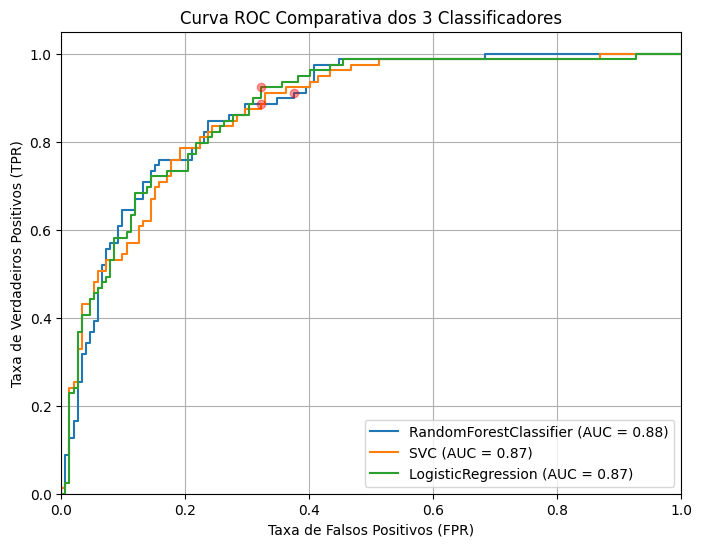

In [150]:
# Definir os classificadores, as probabilidades previstas e as matrizes de confusão
clfs = [random_forest_N, svm_N, logistic_regression_N]  
y_pred_probas = [avalM_RF_n[0], avalM_SVM_n[0], avalM_LR_n[0]]  
conf_matrix = [avalM_RF_n[1], avalM_SVM_n[1], avalM_LR_n[1]] 

# gerar a curva ROC
roc_curve_grafDraw(clfs, y_pred_probas, conf_matrix)

A curva ROC mostra o desempenho dos três classificadores após a normalização dos dados. O Random Forest (linha azul) mantém uma AUC de 0.88, ligeiramente superior á AUC de 0.87 do SVC (laranja) e da Regressão Logística (verde). A proximidade das curvas e os valores da AUC indicam que os três modelos têm desempenhos muito semelhantes em termos de equilíbrio entre a taxa de verdadeiros positivos (TPR) e a taxa de falsos positivos (FPR).

Após a normalização, as curvas ficaram visualmente mais próximas umas das outras, o que indica que a transformação dos dados ajudou a estabilizar o comportamento dos classificadores, permitindo que os modelos explorassem o espaço de decisão todo, sem desvantagens claras para nenhum dos classificadores estudados.

### Gráficos Comparativos dos 3 Classificadores Antes e Depois da Normalização

Para comparar melhor as métricas de desempenho dos modelo antes e depois da normalização dos dados recorreu-se a um gráfico de barras que compara a Accuracy, a Precision, o Recall e o F-Score para cada classificador. Desta forma é mais fácil avaliar o impacto da normalização nos resultados dos classificadores, identificando se houve melhorias na capacidade de prever corretamente os casos positivos e negativos.

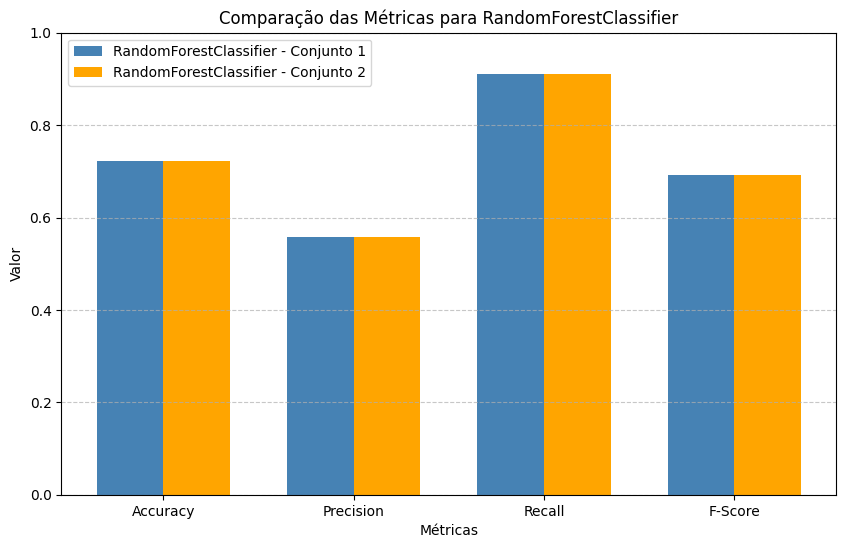

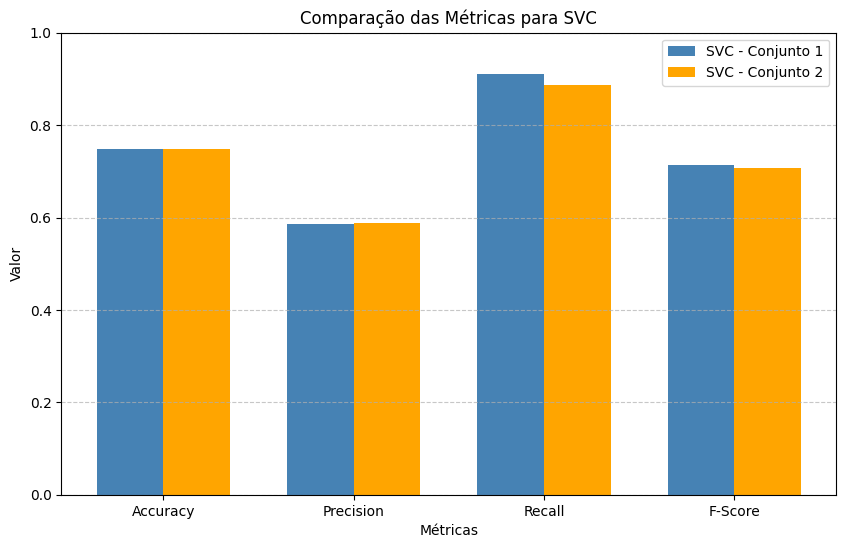

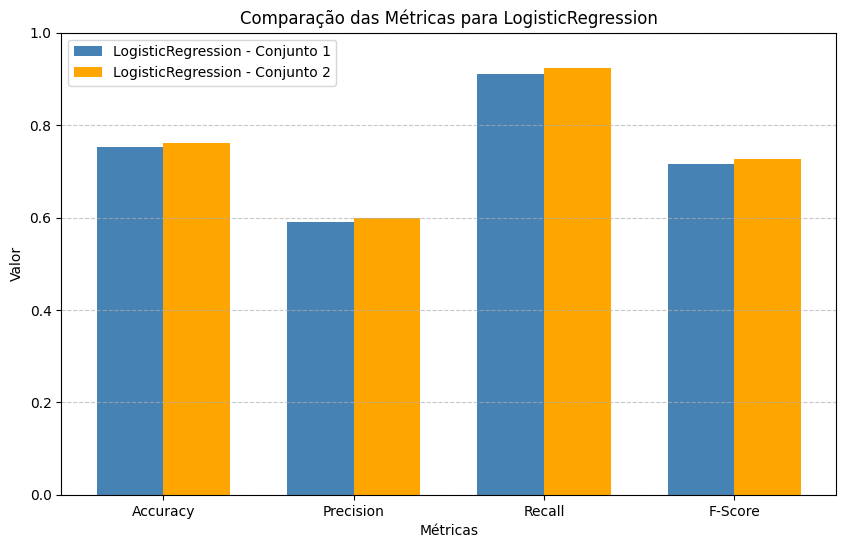

In [151]:
def drawComparGraf(metrics1, metrics2):
    """
    Função para desenhar um gráfico de barras comparando métricas de desempenho entre dois conjuntos de métricas.
    metrics1 e metrics2 são listas com:
    [nome do classificador, accuracy, precision, recall, f_score]
    """
    # Nomes das métricas que serão exibidas no eixo X
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F-Score']
    
    # Separar os valores das métricas, desconsiderando o nome do classificador (primeiro elemento)
    values1 = metrics1[1:]  # Valores das métricas do primeiro conjunto
    values2 = metrics2[1:]  # Valores das métricas do segundo conjunto

    x = np.arange(len(metric_names))
    width = 0.35  # largura das barras no gráfico

    # plot do gráfico 
    plt.figure(figsize=(10, 6))  
    plt.bar(x - width/2, values1, width, label=f"{metrics1[0]} - Conjunto 1", color='steelblue')  
    plt.bar(x + width/2, values2, width, label=f"{metrics2[0]} - Conjunto 2", color='orange')  
    
    plt.xlabel("Métricas")
    plt.ylabel("Valor") 
    plt.title(f"Comparação das Métricas para {metrics1[0]}")  
    plt.xticks(x, metric_names)  
    plt.ylim(0, 1)  
    plt.legend(loc="best")  
    plt.grid(axis='y', linestyle='--', alpha=0.7)  

    # plot do gráfico gerado
    plt.show()

# Definir as métricas de cada modelo para comparar
metricsRF = avalM_RF[2]  # Métricas do Random Forest
metricsSVM = avalM_SVM[2]  # Métricas do SVM
metricsLR = avalM_LR[2]  # Métricas da Regressão Logística

# Métricas normalizadas de cada modelo
metricsRF_n = avalM_RF_n[2]  # Métricas normalizadas do Random Forest
metricsSVM_n = avalM_SVM_n[2]  # Métricas normalizadas do SVM
metricsLR_n = avalM_LR_n[2]  # Métricas normalizadas da Regressão Logística

# desenho dos 3 grafcos
drawComparGraf(metricsRF, metricsRF_n)  # Comparar as métricas do Random Forest
drawComparGraf(metricsSVM, metricsSVM_n)  # Comparar as métricas do SVM
drawComparGraf(metricsLR, metricsLR_n)  # Comparar métricas da Regressão Logística

De maneira geral, tal como se tinha visto anteriormente, observa-se que a normalização não trouxe mudanças significativas em termos de desempenho global, mas contribuiu para um leve ajuste nos resultados. Para o RandomForestClassifier, os valores do recall foram mantidos elevados, o que indica a capacidade do modelo em identificar os casos verdadeiros positivos, embora a precisão tenha permanecido baixa, evidenciando ainda a presença de falsos positivos. No SVC, houve um equilíbrio melhorado entre recall e a precisão, com uma dimuinuição no recall após a normalização, o que torna o modelo mais sensível à escala dos dados. Já no Logistic Regression, os resultados foram satisfatórios, com um leve aumento do recall e do F-score, indicando que a normalização ajudou o modelo a priorizar casos verdadeiros positivos, apresentando ainda um aumento na precisão. 

Por fim, conclui-se que a normalização não alterou muito os resultados obtidos anteriormente, ficando o Random Forest com os mesmos valores e o SVM e a Regressão Logistica como uma descida e um aumento, respetivamente.

### Bibliografia

- Slides disponibilizados via Moodle pelo Professor Gonçalo Marques

- Classificador RandomForest
  - Documentação do RF: https://scikit-learn.org/1.5/modules/generated/sklearn.ensemble.RandomForestClassifier.html
  - Video sobre o RandomForest: https://www.youtube.com/watch?v=jBGxiu8K11o

- Classificador SVM
  - Documentação do SVM: https://scikit-learn.org/dev/modules/generated/sklearn.svm.SVC.html
  - Video sobre o SVM: https://www.youtube.com/watch?v=Y-WFZd9_gtE&t=756s
  - Info sobre os parametros do SVM: https://medium.com/@myselfaman12345/c-and-gamma-in-svm-e6cee48626be 

- Classificador LogisticRegression
  - Documentação do LR: https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html
  - Video sobre o LR: https://www.youtube.com/watch?v=8oE5FLGPDXw
  - Info sobre os parametos do LR: https://medium.com/@rithpansanga/logistic-regression-and-regularization-avoiding-overfitting-and-improving-generalization-e9afdcddd09d
